In [1]:
import pandas as pd
import os

# ============================================================
# STEP 1: DEFINE THE EXACT LOCATION (ABSOLUTE PATH)
# ============================================================
# We use forward slashes / because Python prefers them, even on Windows.
raw_folder = "D:/MSc_Projects/predictive_maintenance_rul/data/raw"

train_path = os.path.join(raw_folder, "train_FD001.txt")
test_path = os.path.join(raw_folder, "test_FD001.txt")
rul_path = os.path.join(raw_folder, "RUL_FD001.txt")

# ============================================================
# STEP 2: DIAGNOSTIC CHECK (Do the files actually exist?)
# ============================================================
print("🔍 Checking file locations...")
print(f"1. Train file exists? {os.path.exists(train_path)}")
print(f"2. Test file exists?  {os.path.exists(test_path)}")
print(f"3. RUL file exists?   {os.path.exists(rul_path)}")

# ============================================================
# STEP 3: LOAD THE DATA
# ============================================================
# We use an IF statement so the code only runs if the files are found.
if os.path.exists(train_path) and os.path.exists(test_path) and os.path.exists(rul_path):
    
    print("\n✅ Files found! Loading data...")
    
    # Define column names (26 columns)
    cols = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
    sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
    cols.extend(sensor_cols)

    # Load data
    train = pd.read_csv(train_path, sep='\s+', header=None, names=cols)
    test = pd.read_csv(test_path, sep='\s+', header=None, names=cols)
    rul = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

    # Verify shapes
    print("\n" + "="*40)
    print("✅ DATA SHAPES")
    print("="*40)
    print(f"Train: {train.shape} | Expected: (20631, 26)")
    print(f"Test:  {test.shape}  | Expected: (13096, 26)")
    print(f"RUL:   {rul.shape}   | Expected: (100, 1)")
    
    print("\n🎉 Stage 2 Data Loading Complete!")

else:
    print("\n❌ ERROR: Python still cannot find the files.")
    print("Please open File Explorer and verify the files are exactly in:")
    print(raw_folder)

🔍 Checking file locations...
1. Train file exists? True
2. Test file exists?  True
3. RUL file exists?   True

✅ Files found! Loading data...

✅ DATA SHAPES
Train: (20631, 26) | Expected: (20631, 26)
Test:  (13096, 26)  | Expected: (13096, 26)
RUL:   (100, 1)   | Expected: (100, 1)

🎉 Stage 2 Data Loading Complete!


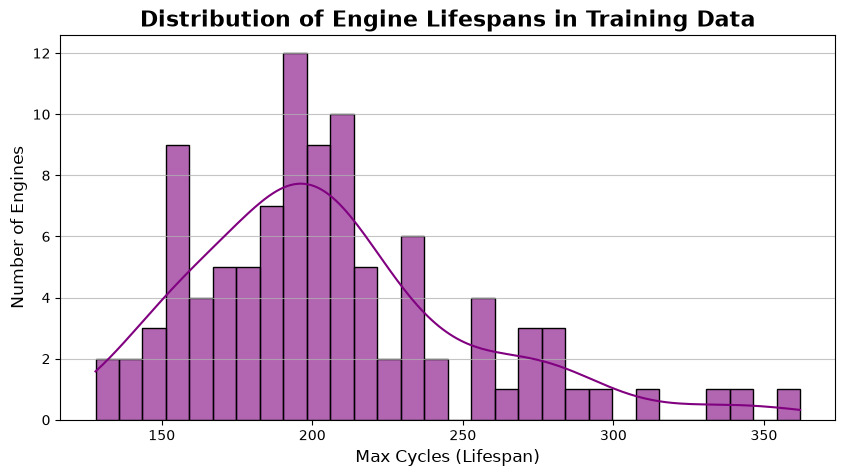

Average lifespan: 206 cycles
Shortest lifespan: 128 cycles
Longest lifespan: 362 cycles


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Find the maximum cycle for every single engine in the training data
# This tells us exactly how many cycles each engine ran before it failed.
max_cycles = train.groupby('unit_number')['time_in_cycles'].max()

# 2. Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(max_cycles, bins=30, kde=True, color='purple',alpha=0.6)
plt.title('Distribution of Engine Lifespans in Training Data', fontsize=16, fontweight='bold')
plt.xlabel('Max Cycles (Lifespan)', fontsize=12)
plt.ylabel('Number of Engines', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Average lifespan: {max_cycles.mean():.0f} cycles")
print(f"Shortest lifespan: {max_cycles.min()} cycles")
print(f"Longest lifespan: {max_cycles.max()} cycles")

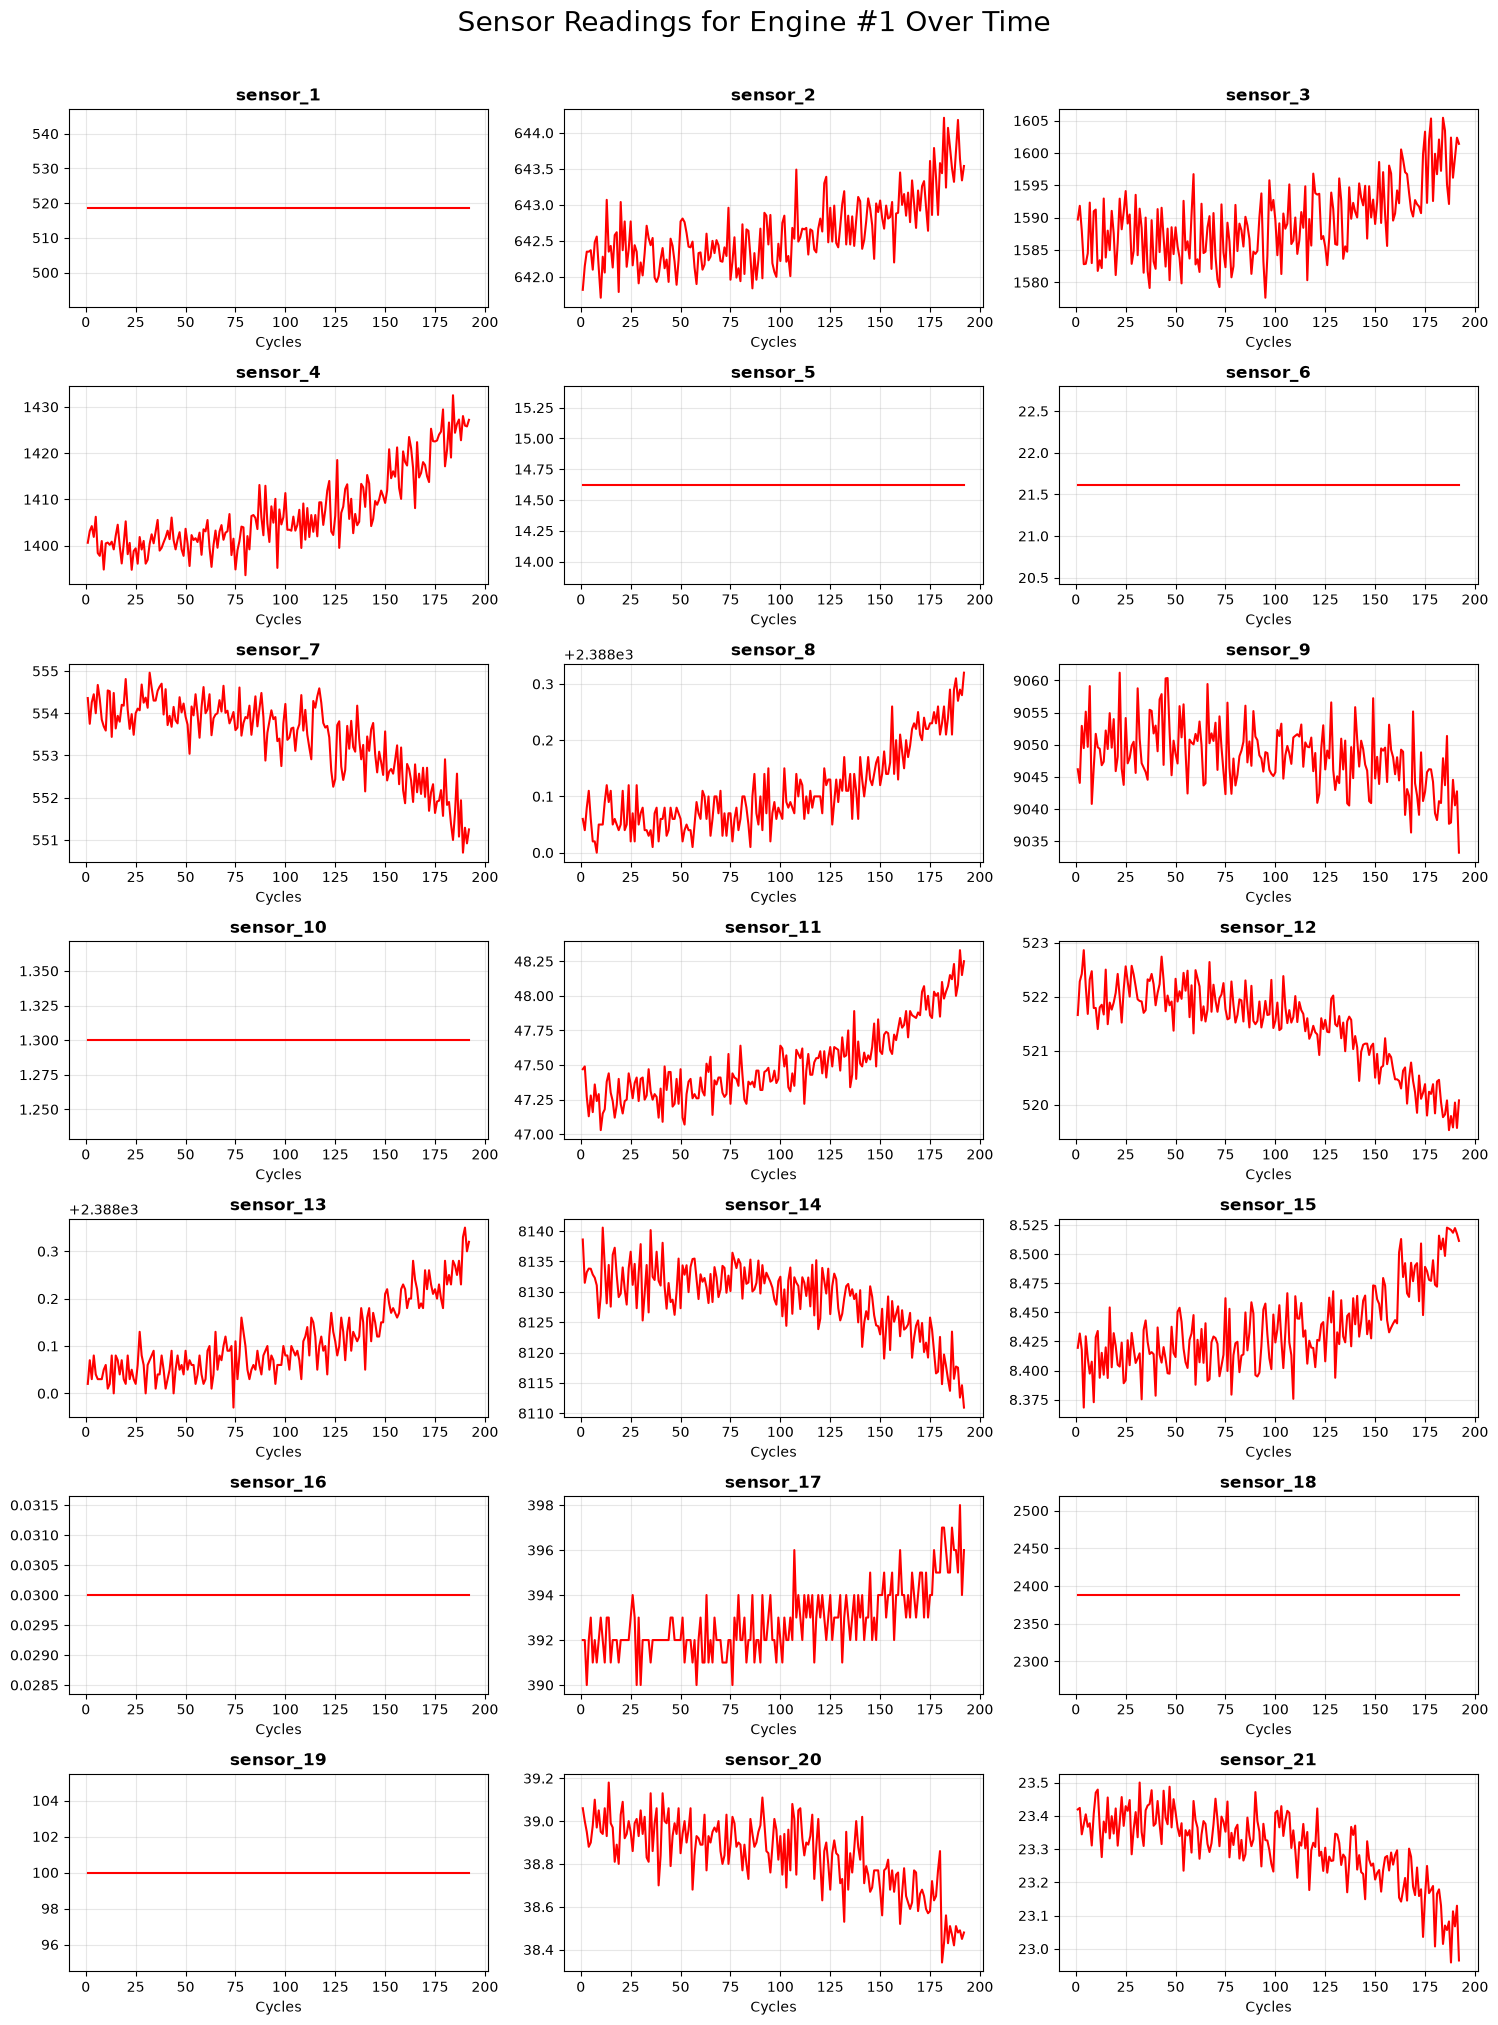

In [3]:
# 1. Isolate just Engine #1 to use as our visual example
engine_1 = train[train['unit_number'] == 1]

# 2. Get a list of just the sensor columns
sensor_cols = [col for col in train.columns if 'sensor' in col]

# 3. Create a grid of plots (7 rows, 3 columns = 21 spots for our 21 sensors)
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.flatten() # Flatten the grid into a 1D list so it's easy to loop through

# 4. Loop through all 21 sensors and plot them
for i, sensor in enumerate(sensor_cols):
    axes[i].plot(engine_1['time_in_cycles'], engine_1[sensor], color='red', linewidth=1.5)
    axes[i].set_title(sensor, fontweight='bold')
    axes[i].set_xlabel('Cycles')
    axes[i].grid(True, alpha=0.3)

# 5. Hide any leftover empty subplots (just in case)
for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sensor Readings for Engine #1 Over Time', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

# ---------------------------------------------------------
# STEP 1: Drop the "Lazy" (Flat) Sensors
# ---------------------------------------------------------
# You found 1, 5, 6, 16, 18, 19. We'll also drop 10 as it's constant in FD001.
flat_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

train_clean = train.drop(columns=flat_sensors)
test_clean = test.drop(columns=flat_sensors)

sensor_cols = [col for col in train_clean.columns if 'sensor' in col]
print(f"✅ Dropped {len(flat_sensors)} flat sensors. {len(sensor_cols)} useful sensors remaining.")

# ---------------------------------------------------------
# STEP 2: Calculate RUL for Training Data
# ---------------------------------------------------------
def add_rul(df, max_rul=125):
    df = df.copy()
    # Find the max cycle for each engine
    max_cycles = df.groupby('unit_number')['time_in_cycles'].transform('max')
    
    # Calculate raw RUL (Max Cycle - Current Cycle)
    df['RUL'] = max_cycles - df['time_in_cycles']
    
    # Cap RUL at 125 (Standard academic practice for C-MAPSS)
    df['RUL'] = df['RUL'].clip(upper=max_rul)
    return df

train_clean = add_rul(train_clean)

# ---------------------------------------------------------
# STEP 3: Calculate RUL for Test Data
# ---------------------------------------------------------
# The 'rul' dataframe has the true RUL for the VERY LAST cycle of each test engine.
# We work backwards to find the RUL for every prior cycle in the test set.
test_clean = test_clean.copy()
test_clean['RUL'] = 0 

for i in range(1, 101): # 100 engines in test set
    engine_mask = test_clean['unit_number'] == i
    max_cycle = test_clean.loc[engine_mask, 'time_in_cycles'].max()
    
    # The true RUL at the end is in the 'rul' dataframe (index i-1)
    rul_at_end = rul.iloc[i-1]['RUL']
    
    # RUL at any cycle t = rul_at_end + (max_cycle - t)
    test_clean.loc[engine_mask, 'RUL'] = rul_at_end + (max_cycle - test_clean.loc[engine_mask, 'time_in_cycles'])

# Cap test RUL at 125 as well
test_clean['RUL'] = test_clean['RUL'].clip(upper=125)

print("✅ RUL calculated and capped at 125 for both Train and Test.")

✅ Dropped 7 flat sensors. 14 useful sensors remaining.
✅ RUL calculated and capped at 125 for both Train and Test.


In [25]:
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# STEP 4: Normalize Sensor Data
# ---------------------------------------------------------
scaler = StandardScaler()

# 1. FIT on train data (learn the mean and standard deviation)
# 2. TRANSFORM train data
train_clean[sensor_cols] = scaler.fit_transform(train_clean[sensor_cols])

# 3. TRANSFORM test data (apply the rules learned from train ONLY)
test_clean[sensor_cols] = scaler.transform(test_clean[sensor_cols])

print("✅ Sensor data normalized using StandardScaler (Leakage prevented!).")

✅ Sensor data normalized using StandardScaler (Leakage prevented!).


In [26]:
# ---------------------------------------------------------
# STEP 5: Generate Sliding Window Sequences for LSTM
# ---------------------------------------------------------
# LSTMs need 3D data: (Samples, Time Steps, Features)
SEQ_LENGTH = 30

def generate_sequences(df, seq_length=30):
    X, y = [], []
    
    # Process one engine at a time to avoid mixing data between engines!
    for unit_id in df['unit_number'].unique():
        engine_data = df[df['unit_number'] == unit_id].sort_values('time_in_cycles')
        
        sensor_data = engine_data[sensor_cols].values
        rul_data = engine_data['RUL'].values
        
        # Slide the window
        for i in range(len(engine_data) - seq_length + 1):
            X.append(sensor_data[i : i + seq_length])
            y.append(rul_data[i + seq_length - 1]) # Target is the RUL at the END of the window
            
    return np.array(X), np.array(y)

print("Generating sequences... (This might take a few seconds)")
X_train, y_train = generate_sequences(train_clean, SEQ_LENGTH)
X_test, y_test = generate_sequences(test_clean, SEQ_LENGTH)

print("\n" + "="*40)
print("✅ SEQUENCE SHAPES (Ready for LSTM)")
print("="*40)
print(f"X_train: {X_train.shape} | (Samples, 30 time steps, {len(sensor_cols)} sensors)")
print(f"y_train: {y_train.shape} | (Samples,)")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

Generating sequences... (This might take a few seconds)

✅ SEQUENCE SHAPES (Ready for LSTM)
X_train: (17731, 30, 14) | (Samples, 30 time steps, 14 sensors)
y_train: (17731,) | (Samples,)
X_test:  (10196, 30, 14)
y_test:  (10196,)


In [27]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Sensors: {len(sensor_cols)}")


X_train shape: (17731, 30, 14)
X_test shape:  (10196, 30, 14)
y_train shape: (17731,)
y_test shape:  (10196,)
Sensors: 14


In [28]:
# ============================================================
# STAGE 5: BASELINE MODEL — Feature Engineering
# ============================================================
# Convert 3D sequences (samples, 30, 14) into 2D flat features (samples, 70)
# Each window gets: mean, std, min, max, last_value per sensor

def flatten_sequences(X):
    """
    Takes X of shape (samples, seq_length, n_features)
    Returns flat array of shape (samples, n_features * 5)
    """
    n_samples = X.shape[0]
    n_features = X.shape[2]
    
    # Calculate 5 statistics along the time axis (axis=1)
    mean_vals = X.mean(axis=1)       # shape: (samples, 14)
    std_vals = X.std(axis=1)         # shape: (samples, 14)
    min_vals = X.min(axis=1)         # shape: (samples, 14)
    max_vals = X.max(axis=1)         # shape: (samples, 14)
    last_vals = X[:, -1, :]          # shape: (samples, 14) — last time step
    
    # Stack them side by side: (samples, 70)
    flat = np.concatenate([mean_vals, std_vals, min_vals, max_vals, last_vals], axis=1)
    
    return flat

print("Flattening sequences...")
X_train_flat = flatten_sequences(X_train)
X_test_flat = flatten_sequences(X_test)

print(f"\n✅ Flattened shapes:")
print(f"X_train_flat: {X_train_flat.shape} | Expected: (17432, 70)")
print(f"X_test_flat:  {X_test_flat.shape}  | Expected: (10897, 70)")

Flattening sequences...

✅ Flattened shapes:
X_train_flat: (17731, 70) | Expected: (17432, 70)
X_test_flat:  (10196, 70)  | Expected: (10897, 70)


In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# STAGE 5: Train XGBoost Regressor
# ============================================================

print("Training XGBoost baseline... (may take 30-60 seconds)")

xgb_model = XGBRegressor(
    n_estimators=200,        # Number of trees
    max_depth=6,             # Depth of each tree
    learning_rate=0.1,       # Step size
    subsample=0.8,           # Use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,    # Use 80% of features per tree
    random_state=42,         # Reproducibility
    n_jobs=-1                # Use all CPU cores (your Ryzen 7 has 8 cores/16 threads!)
)

xgb_model.fit(X_train_flat, y_train)

print("✅ XGBoost training complete!")

Training XGBoost baseline... (may take 30-60 seconds)
✅ XGBoost training complete!


In [30]:
# ============================================================
# STAGE 5: Evaluate Baseline
# ============================================================

# Predict on test set
y_pred_train = xgb_model.predict(X_train_flat)
y_pred_test = xgb_model.predict(X_test_flat)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

# Print results clearly
print("\n" + "="*50)
print("📊 XGBOOST BASELINE RESULTS")
print("="*50)
print(f"{'Metric':<15} {'Train':<12} {'Test':<12}")
print("-"*50)
print(f"{'RMSE':<15} {train_rmse:<12.2f} {test_rmse:<12.2f}")
print(f"{'MAE':<15} {train_mae:<12.2f} {test_mae:<12.2f}")
print("="*50)
print(f"\n🎯 BASELINE TEST RMSE: {test_rmse:.2f} cycles")
print(f"🎯 BASELINE TEST MAE:  {test_mae:.2f} cycles")
print(f"\n👉 Your LSTM in Stage 6 must beat RMSE = {test_rmse:.2f} to justify its complexity!")


📊 XGBOOST BASELINE RESULTS
Metric          Train        Test        
--------------------------------------------------
RMSE            3.25         19.26       
MAE             2.37         14.67       

🎯 BASELINE TEST RMSE: 19.26 cycles
🎯 BASELINE TEST MAE:  14.67 cycles

👉 Your LSTM in Stage 6 must beat RMSE = 19.26 to justify its complexity!


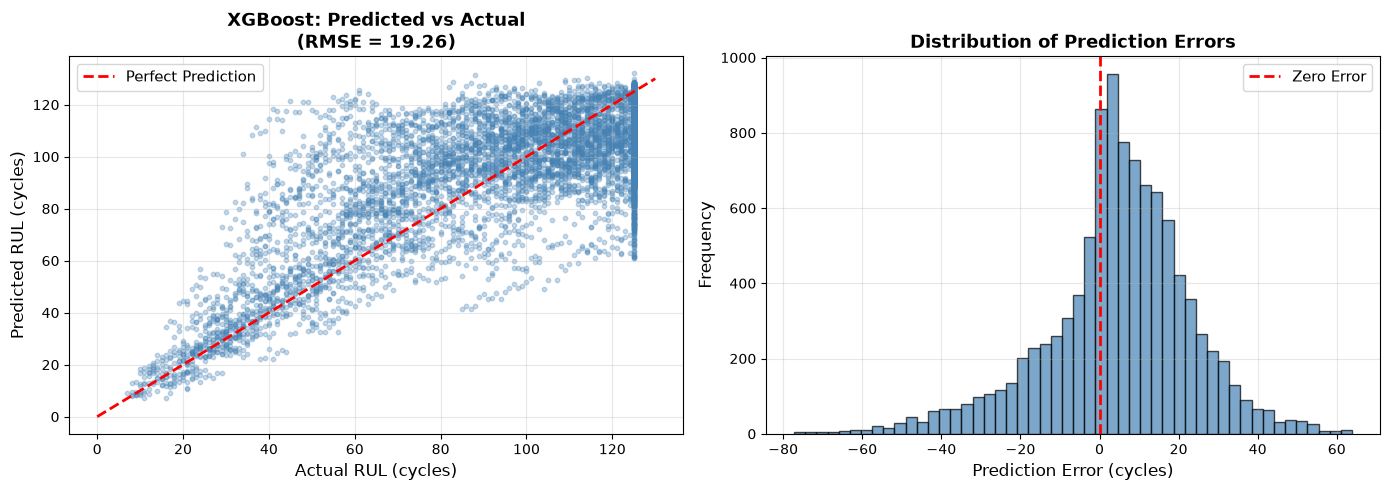

In [31]:
# ============================================================
# STAGE 5: Visualize Baseline Performance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual scatter
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 130], [0, 130], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=12)
axes[0].set_title(f'XGBoost: Predicted vs Actual\n(RMSE = {test_rmse:.2f})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Error distribution
errors = y_test - y_pred_test
axes[1].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error (cycles)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Prediction Errors', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Set device to CPU (Tailored for your Lenovo AMD laptop)
device = torch.device('cpu')
print(f"🔥 Using device: {device}")

# 2. Convert numpy arrays to PyTorch Tensors
# X is already 3D: (samples, 30 time steps, 14 sensors) - perfect for LSTM!
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

# y needs to be 2D: (samples, 1) for the loss function
y_train_t = torch.FloatTensor(y_train).view(-1, 1).to(device)
y_test_t = torch.FloatTensor(y_test).view(-1, 1).to(device)

# 3. Create Datasets and DataLoaders
# Batch size 256 is a good sweet spot for CPU training speed
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"✅ DataLoaders ready. Batch size: 256")

🔥 Using device: cpu
✅ DataLoaders ready. Batch size: 256


In [33]:
# ============================================================
# STAGE 6: LSTM Architecture
# ============================================================
class LSTMRUL(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMRUL, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # The LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        
        # The fully connected output layer (maps hidden state to 1 RUL value)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # We only want the prediction from the VERY LAST time step in the sequence
        out = out[:, -1, :] 
        
        # Pass through final linear layer
        out = self.fc(out)
        return out

# Hyperparameters
INPUT_SIZE = X_train.shape[2]  # 14 sensors
HIDDEN_SIZE = 64               # 64 memory cells (good for CPU)
NUM_LAYERS = 2                 # 2 stacked LSTM layers

model = LSTMRUL(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
print(f"✅ LSTM Model created with {sum(p.numel() for p in model.parameters()):,} trainable parameters.")

✅ LSTM Model created with 53,825 trainable parameters.


In [35]:
# ============================================================
# STAGE 6: Training Loop with Early Stopping
# ============================================================
import os

# ✅ PRECISE FIX: Absolute path to the REAL models folder (project root)
PROJECT_ROOT = "D:/MSc_Projects/predictive_maintenance_rul"
models_dir = os.path.join(PROJECT_ROOT, "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "best_lstm.pth")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
best_rmse = float('inf')
patience = 7
patience_counter = 0

print("Starting LSTM Training... (This will take 1-3 minutes on your CPU)")
print("-" * 50)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t)
        test_mse = criterion(test_preds, y_test_t).item()
        test_rmse = np.sqrt(test_mse)
        
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        patience_counter = 0
        torch.save(model.state_dict(), model_path)   # ✅ Absolute path now
        status = "👑 Best Model Saved!"
    else:
        patience_counter += 1
        status = f"⏳ Waiting... ({patience_counter}/{patience})"
        
    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Test RMSE: {test_rmse:.2f} | {status}")
    
    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}!")
        break

model.load_state_dict(torch.load(model_path))
print(f"\n🎉 Training Complete! Best Test RMSE achieved: {best_rmse:.2f}")

Starting LSTM Training... (This will take 1-3 minutes on your CPU)
--------------------------------------------------
Epoch 01/50 | Train Loss: 6608.6739 | Test RMSE: 95.91 | 👑 Best Model Saved!
Epoch 02/50 | Train Loss: 6011.1517 | Test RMSE: 91.74 | 👑 Best Model Saved!
Epoch 03/50 | Train Loss: 5445.5544 | Test RMSE: 87.73 | 👑 Best Model Saved!
Epoch 04/50 | Train Loss: 4950.7409 | Test RMSE: 83.86 | 👑 Best Model Saved!
Epoch 05/50 | Train Loss: 4485.7730 | Test RMSE: 80.12 | 👑 Best Model Saved!
Epoch 06/50 | Train Loss: 4064.9804 | Test RMSE: 76.52 | 👑 Best Model Saved!
Epoch 07/50 | Train Loss: 3683.5712 | Test RMSE: 73.04 | 👑 Best Model Saved!
Epoch 08/50 | Train Loss: 3339.5610 | Test RMSE: 69.70 | 👑 Best Model Saved!
Epoch 09/50 | Train Loss: 3016.5174 | Test RMSE: 66.46 | 👑 Best Model Saved!
Epoch 10/50 | Train Loss: 2724.1432 | Test RMSE: 63.36 | 👑 Best Model Saved!
Epoch 11/50 | Train Loss: 2467.8535 | Test RMSE: 60.37 | 👑 Best Model Saved!
Epoch 12/50 | Train Loss: 2223.8889

🏆 FINAL MODEL COMPARISON
Model        RMSE       MAE       
--------------------------------------------------
XGBoost      19.26      14.67     
LSTM         15.89      12.16     


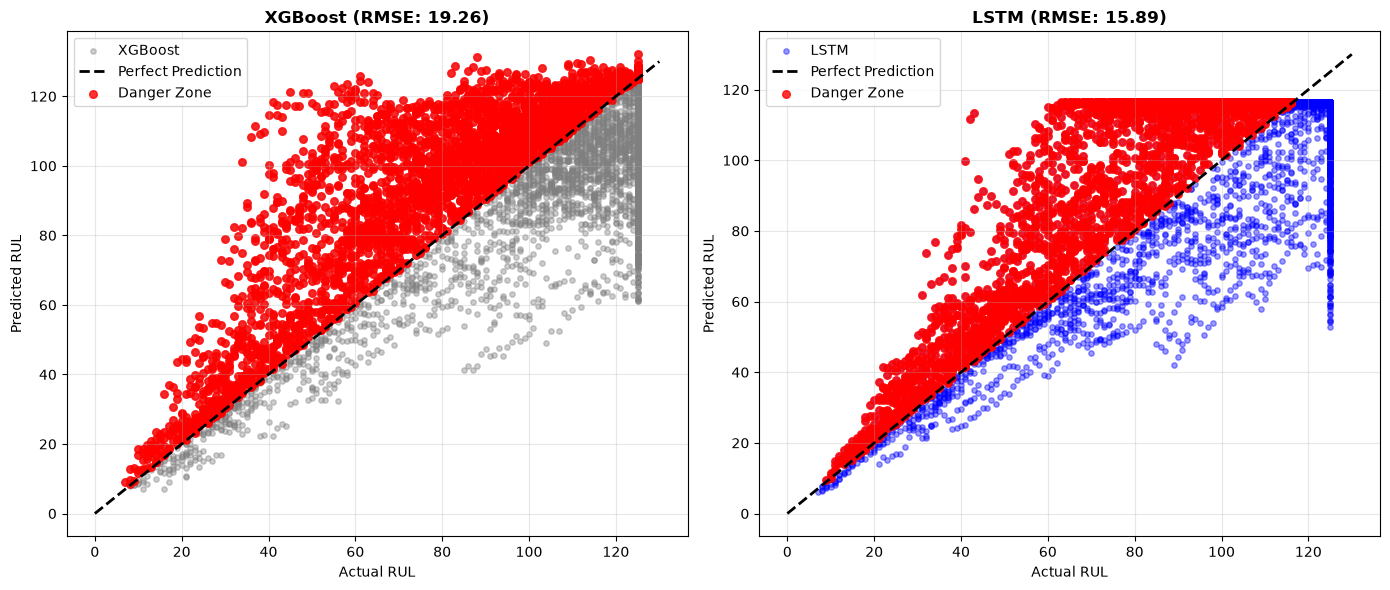

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# STAGE 6: Final Evaluation & Visualization
# ============================================================

# 1. Get LSTM Predictions
model.eval()
with torch.no_grad():
    lstm_preds_t = model(X_test_t)
    lstm_preds = lstm_preds_t.cpu().numpy().flatten()

# 2. Get XGBoost Predictions (from Stage 5)
xgb_preds = xgb_model.predict(X_test_flat)

# 3. Calculate Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_preds))
lstm_mae = mean_absolute_error(y_test, lstm_preds)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)

print("="*50)
print("🏆 FINAL MODEL COMPARISON")
print("="*50)
print(f"{'Model':<12} {'RMSE':<10} {'MAE':<10}")
print("-"*50)
print(f"{'XGBoost':<12} {xgb_rmse:<10.2f} {xgb_mae:<10.2f}")
print(f"{'LSTM':<12} {lstm_rmse:<10.2f} {lstm_mae:<10.2f}")
print("="*50)

# 4. The Skeptic's Plot: Danger Zone vs Safe Zone
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: XGBoost ---
axes[0].scatter(y_test, xgb_preds, alpha=0.4, s=15, color='gray', label='XGBoost')
axes[0].plot([0, 130], [0, 130], 'k--', linewidth=2, label='Perfect Prediction')
xgb_danger_mask = xgb_preds > y_test
axes[0].scatter(y_test[xgb_danger_mask], xgb_preds[xgb_danger_mask], color='red', s=30, alpha=0.8, label='Danger Zone')
axes[0].set_title(f'XGBoost (RMSE: {xgb_rmse:.2f})', fontweight='bold')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: LSTM ---
axes[1].scatter(y_test, lstm_preds, alpha=0.4, s=15, color='blue', label='LSTM')
axes[1].plot([0, 130], [0, 130], 'k--', linewidth=2, label='Perfect Prediction')
lstm_danger_mask = lstm_preds > y_test
axes[1].scatter(y_test[lstm_danger_mask], lstm_preds[lstm_danger_mask], color='red', s=30, alpha=0.8, label='Danger Zone')
axes[1].set_title(f'LSTM (RMSE: {lstm_rmse:.2f})', fontweight='bold')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Initializing SHAP GradientExplainer... (this takes a few seconds)
🔍 Explaining prediction for a failing engine...
Actual RUL: 19 cycles | Predicted RUL: 31 cycles
Calculating SHAP values...


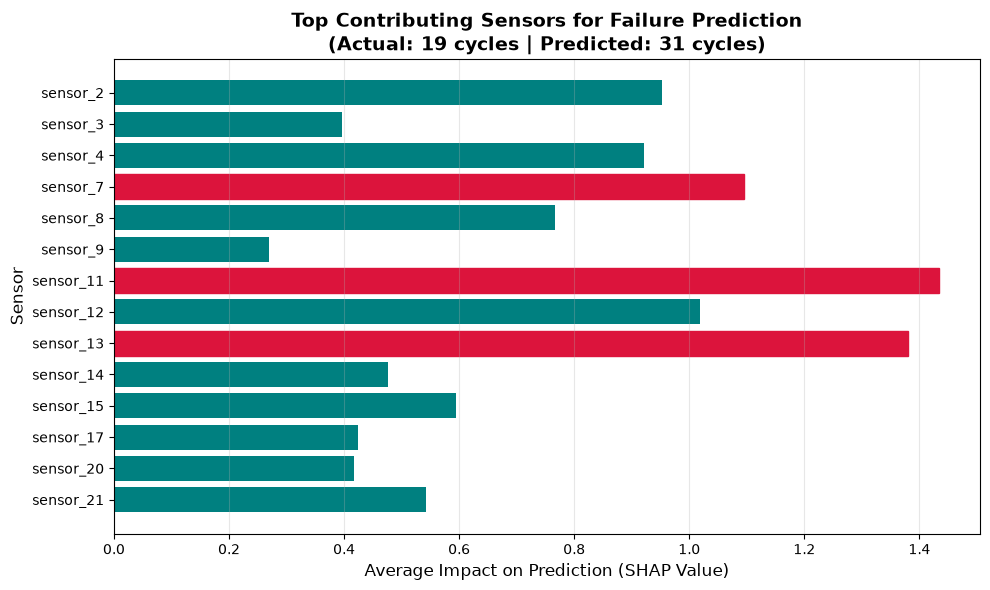


✅ SHAP Explanation Complete! The crimson bars are the sensors driving the failure prediction.


In [43]:
import shap

# ============================================================
# STAGE 7: Explainability (SHAP) - Bulletproof Shape Fix
# ============================================================

# 1. Create a Background Dataset
background_indices = np.random.choice(X_train_t.shape[0], 50, replace=False)
background = X_train_t[background_indices]

print("Initializing SHAP GradientExplainer... (this takes a few seconds)")
explainer = shap.GradientExplainer(model, background)

# 2. Select a "Dying Engine" Sequence to Explain
danger_indices = np.where(y_test < 20)[0]
explain_idx = danger_indices[0] 

sequence_to_explain = X_test_t[explain_idx:explain_idx+1] 
actual_rul = y_test[explain_idx]
predicted_rul = lstm_preds[explain_idx]

print(f"🔍 Explaining prediction for a failing engine...")
print(f"Actual RUL: {actual_rul:.0f} cycles | Predicted RUL: {predicted_rul:.0f} cycles")

# 3. Calculate SHAP Values
print("Calculating SHAP values...")
sv = explainer.shap_values(sequence_to_explain)

# ✅ BULLETPROOF FIX: Squeeze ALL dimensions of size 1
# This safely strips away batch dimensions or list wrappers 
# without crashing if axis 0 isn't 1.
sv = np.array(sv).squeeze()

# 4. Aggregate Importance Across Time
# Now sv is guaranteed to be (30 time_steps, 14 sensors)
sensor_importance = np.abs(sv).mean(axis=0)

# 5. Plot the Results
plt.figure(figsize=(10, 6))

bars = plt.barh(sensor_cols, sensor_importance, color='teal')

top_3_indices = np.argsort(sensor_importance)[-3:]
for i in top_3_indices:
    bars[i].set_color('crimson')

plt.xlabel('Average Impact on Prediction (SHAP Value)', fontsize=12)
plt.ylabel('Sensor', fontsize=12)
plt.title(f'Top Contributing Sensors for Failure Prediction\n(Actual: {actual_rul:.0f} cycles | Predicted: {predicted_rul:.0f} cycles)', 
          fontsize=14, fontweight='bold')

plt.gca().invert_yaxis() 
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ SHAP Explanation Complete! The crimson bars are the sensors driving the failure prediction.")